# **Directed percolation in Rust-Python**

First stab at implementing DP in Rust with a Python convenience wrapper.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from numpy.typing import NDArray
from dprs import sim

In [2]:
n_x: int = 10_000
n_y: int = 10_000
n_iterations: int = 100
slow_factor: int = 10
n_threads: int = 16

Execute the Rust-coded sim:

In [3]:
raw_lattice: list = sim.dp(
    n_x, n_y, n_iterations, slow_factor, n_threads,
)

dp: 10000 10000 100 10 16

Grid width:  x=10000
Grid height: y=10000
Iterations:  n=100
Slow factor: s=10
Threads: n_threads=16

Serial:   34.977s
Parallel: 3.033s
Speedup => 11.53x



The final model lattice is returned as a 1d list; next we convert it into the correctly shaped numpy array (2d grid):

In [4]:
lattice: NDArray = np.array(raw_lattice, dtype=np.bool,).reshape(n_x, n_y,)

Plot the lower-left portion of the lattice:

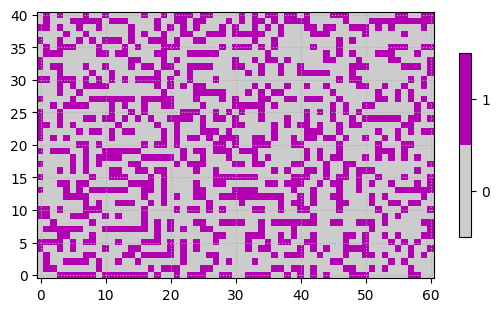

In [5]:
color_map = ListedColormap(((0.8, 0.8, 0.8,), (0.7, 0, 0.7),))
plt.imshow(((lattice[0:61,0:41].T)), cmap=color_map, origin="lower",)
color_bar = plt.colorbar(
    ticks=(0.25, 0.75,), shrink=0.5*(n_y/n_x)**0.25, aspect=15,
)
color_bar.set_ticklabels((0, 1,),)
plt.grid(ls=":")
plt.show()